## PQK-SVM WIG20 BANKI - wersja 18.09.2026 - 3. Topologia Gwiazdy

In [2]:
%pip install statsmodels
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 5.6 MB/s eta 0:00:09
   -- ------------------------------------- 3.4/48.9 MB 12.6 MB/s eta 0:00:04
   ------ --------------------------------- 7.9/48.9 MB 16.8 MB/s eta 0:00:03
   ---------- ----------------------------- 12.8/48.9 MB 19.2 MB/s eta 0:00:02
   ------------- -------------------------- 17.0/48.9 MB 19.2 MB/s eta 0:00:02
   ------------------ --------------------- 22.3/48.9 MB 20.7 MB/s eta 0:00:02
   ---------------------- ----------------- 28.0/48.9 MB 21.7 MB/s eta 0:00:01
   --------------------------- ------------ 33.3/48.9 MB 22.2 MB/s eta 0:00:01
   ------------------------------- -------- 38.8/48.9 MB 22.8 MB/s eta 0:00:01
   ----------------------------------- ---- 43.3/48.9 MB 22.9 MB/s eta 0:00:01
   ---------------------------------------  48.5/48.9 MB 23.0 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 21.8 MB/

Z XGBoost

>>> Wczytywanie surowych rzutów QPU z: phi_odra_wigbanki_5q_star_reps1_shots4000_v1.npz
>>> Transformacja surowych rzutów X,Y,Z na współrzędne sferyczne...
>>> Start Walk-Forward: Klasyczny vs QPU Surowe vs QPU Sferyczne...

--- WYNIKI MISJI RATUNKOWEJ DLA DRZEW DECYZYJNYCH ---


,Accuracy,Bal Acc,F1,AUC,MCC
XGBoost Klasyczny (Surowe Cechy),0.5127,0.5035,0.5744,0.4991,0.0070
"XGBoost Naiwny QPU (Kwadratowe cięcie X,Y,Z)",0.5460,0.5285,0.6317,0.5062,0.0611
XGBoost Uratowany QPU (Wsp. Sferyczne),0.5382,0.5229,0.6181,0.5115,0.0481


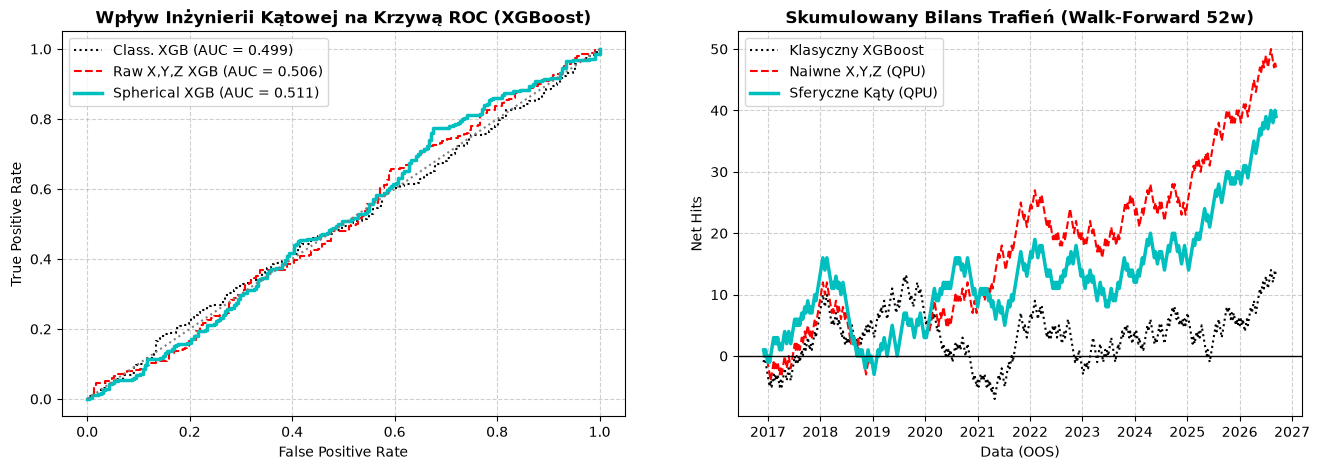

In [3]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef
)

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA I PRZYCZYNOWE SKALOWANIE
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         
    'pbv_peo', 'rentownosc_10y',   
    'pbv_san', 'eurpln',           
    'pbv_ing', 'wig20',            
    'pbv_mbk', 'zmiennosc'         
]

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    current_scaled = np.clip(current_scaled, 0.0, 2 * np.pi)
    
    X_norm_list.append(current_scaled)
    valid_indices.append(t)

X_quantum = np.array(X_norm_list)
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]
X_raw_valid = X_raw[valid_indices]

# ==========================================
# 2. WCZYTYWANIE CACHE Z QPU ODRA
# ==========================================
# Używamy tej samej nazwy pliku co w zwycięskim teście SVM
cache_filename = "phi_odra_wigbanki_5q_star_reps1_shots4000_v1.npz"

if not os.path.exists(cache_filename):
    raise FileNotFoundError(f"Brak pliku {cache_filename}. Uruchom najpierw bazowy skrypt zapisujący wyniki QPU Odra.")

print(f">>> Wczytywanie surowych rzutów QPU z: {cache_filename}")
cache = np.load(cache_filename, allow_pickle=True)
Phi_raw = cache["phi"]
num_qubits = 5

# ==========================================
# 3. QUANTUM FEATURE ENGINEERING (SFERYCZNA TRANSFORMACJA)
# ==========================================
def raw_to_spherical(phi_matrix, n_qubits):
    """
    Przekształca rzuty ortogonalne (X, Y, Z) na sferyczne (Promień r, Kąt Theta, Kąt Phi).
    Dzięki temu drzewa decyzyjne mogą łatwo ciąć przestrzeń kątową.
    """
    N = phi_matrix.shape[0]
    spherical = np.zeros((N, n_qubits * 3))
    
    for q in range(n_qubits):
        x = phi_matrix[:, 3 * q + 0]
        y = phi_matrix[:, 3 * q + 1]
        z = phi_matrix[:, 3 * q + 2]
        
        # 1. Długość wektora Blocha (purity / wskaźnik dekoherencji)
        r = np.sqrt(x**2 + y**2 + z**2) + 1e-8
        
        # 2. Kąt polarny Theta (pochylenie Z)
        theta = np.arccos(np.clip(z / r, -1.0, 1.0))
        
        # 3. Kąt azymutalny Phi (rotacja wokół osi Z)
        phi = np.arctan2(y, x)
        
        spherical[:, 3 * q + 0] = r
        spherical[:, 3 * q + 1] = theta
        spherical[:, 3 * q + 2] = phi
        
    return spherical

print(">>> Transformacja surowych rzutów X,Y,Z na współrzędne sferyczne...")
Phi_spherical = raw_to_spherical(Phi_raw, num_qubits)

# ==========================================
# 4. EWALUACJA WALK-FORWARD (EKSTREMALNA REGULARYZACJA)
# ==========================================
TRAIN_WINDOW = 52
n_samples = len(y)

# Konfiguracja XGBoost: Decision Stumps (max_depth=1) z brutalną karą L2 (reg_lambda=50)
xgb_params = {
    "max_depth": 1,
    "learning_rate": 0.05,
    "n_estimators": 150,
    "reg_lambda": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "random_state": 42
}

results = {"y_true": [], "dates": [], "score_class": [], "score_raw": [], "score_spherical": []}

print(">>> Start Walk-Forward: Klasyczny vs QPU Surowe vs QPU Sferyczne...")

for t in range(TRAIN_WINDOW, n_samples):
    # Wycinanie okna krok po kroku
    X_tr_class, X_te_class = X_raw_valid[t - TRAIN_WINDOW : t], X_raw_valid[t : t + 1]
    P_raw_tr, P_raw_te = Phi_raw[t - TRAIN_WINDOW : t], Phi_raw[t : t + 1]
    P_sph_tr, P_sph_te = Phi_spherical[t - TRAIN_WINDOW : t], Phi_spherical[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    # Skalowanie (drzewa nie wymagają skalowania do predykcji, ale robimy to dla czystości wejściowej)
    scaler_class = StandardScaler().fit(X_tr_class)
    scaler_raw = StandardScaler().fit(P_raw_tr)
    scaler_sph = StandardScaler().fit(P_sph_tr)
    
    # 1. XGBoost Klasyczny (Cechy bazowe)
    clf_class = XGBClassifier(**xgb_params).fit(scaler_class.transform(X_tr_class), y_tr)
    results["score_class"].append(clf_class.predict_proba(scaler_class.transform(X_te_class))[0, 1])
    
    # 2. XGBoost Naiwny (Surowe X,Y,Z z Odry)
    clf_raw = XGBClassifier(**xgb_params).fit(scaler_raw.transform(P_raw_tr), y_tr)
    results["score_raw"].append(clf_raw.predict_proba(scaler_raw.transform(P_raw_te))[0, 1])
    
    # 3. XGBoost Sferyczny (Uratowany, Kwantowy Feature Engineering)
    clf_sph = XGBClassifier(**xgb_params).fit(scaler_sph.transform(P_sph_tr), y_tr)
    results["score_spherical"].append(clf_sph.predict_proba(scaler_sph.transform(P_sph_te))[0, 1])

for k in results: results[k] = np.array(results[k])

y_true = results["y_true"]
pred_class = (results["score_class"] > 0.5).astype(int)
pred_raw = (results["score_raw"] > 0.5).astype(int)
pred_sph = (results["score_spherical"] > 0.5).astype(int)

# ==========================================
# 5. METRYKI I WIZUALIZACJA
# ==========================================
def compute_metrics(y_t, pred, scores):
    return {
        "Accuracy": accuracy_score(y_t, pred),
        "Bal Acc": balanced_accuracy_score(y_t, pred),
        "F1": f1_score(y_t, pred, zero_division=0),
        "AUC": roc_auc_score(y_t, scores),
        "MCC": matthews_corrcoef(y_t, pred)
    }

df_metrics = pd.DataFrame({
    "XGBoost Klasyczny (Surowe Cechy)": compute_metrics(y_true, pred_class, results["score_class"]),
    "XGBoost Naiwny QPU (Kwadratowe cięcie X,Y,Z)": compute_metrics(y_true, pred_raw, results["score_raw"]),
    "XGBoost Uratowany QPU (Wsp. Sferyczne)": compute_metrics(y_true, pred_sph, results["score_spherical"])
}).T

print("\n--- WYNIKI MISJI RATUNKOWEJ DLA DRZEW DECYZYJNYCH ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
fpr_class, tpr_class, _ = roc_curve(y_true, results["score_class"])
fpr_raw, tpr_raw, _ = roc_curve(y_true, results["score_raw"])
fpr_sph, tpr_sph, _ = roc_curve(y_true, results["score_spherical"])

ax[0].plot(fpr_class, tpr_class, 'k:', label=f'Class. XGB (AUC = {df_metrics.loc["XGBoost Klasyczny (Surowe Cechy)", "AUC"]:.3f})')
ax[0].plot(fpr_raw, tpr_raw, 'r--', label=f'Raw X,Y,Z XGB (AUC = {df_metrics.loc["XGBoost Naiwny QPU (Kwadratowe cięcie X,Y,Z)", "AUC"]:.3f})')
ax[0].plot(fpr_sph, tpr_sph, 'c-', lw=2.5, label=f'Spherical XGB (AUC = {df_metrics.loc["XGBoost Uratowany QPU (Wsp. Sferyczne)", "AUC"]:.3f})')
ax[0].plot([0, 1], [0, 1], 'gray', linestyle=':')
ax[0].set_title('Wpływ Inżynierii Kątowej na Krzywą ROC (XGBoost)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

ax[1].plot(results["dates"], np.cumsum(np.where(pred_class == y_true, 1, -1)), 'k:', label='Klasyczny XGBoost')
ax[1].plot(results["dates"], np.cumsum(np.where(pred_raw == y_true, 1, -1)), 'r--', label='Naiwne X,Y,Z (QPU)')
ax[1].plot(results["dates"], np.cumsum(np.where(pred_sph == y_true, 1, -1)), 'c-', lw=2.5, label='Sferyczne Kąty (QPU)')
ax[1].axhline(0, color='black', lw=1)
ax[1].set_title('Skumulowany Bilans Trafień (Walk-Forward 52w)', fontweight='bold')
ax[1].set_xlabel('Data (OOS)')
ax[1].set_ylabel('Net Hits')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.show()